In [19]:
import numpy as np
import pandas as pd
df = pd.read_csv("city_day.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [20]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [22]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

df.drop('Xylene', axis=1, inplace=True)

num_cols = df.select_dtypes(include='number').columns

df[num_cols] = df.groupby('City')[num_cols].transform(
    lambda x: x.fillna(x.median())
)

In [24]:
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,58.37,107.96,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,384.5,NaN
1,Ahmedabad,2015-01-02,58.37,107.96,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,384.5,NaN
2,Ahmedabad,2015-01-03,58.37,107.96,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,384.5,NaN
3,Ahmedabad,2015-01-04,58.37,107.96,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,384.5,NaN
4,Ahmedabad,2015-01-05,58.37,107.96,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,384.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,54.0,Satisfactory


In [25]:
df.isnull().sum()

City             0
Date             0
PM2.5            0
PM10          2009
NO               0
NO2              0
NOx           1169
NH3           2009
CO               0
SO2              0
O3             162
Benzene       2732
Toluene       4010
AQI              0
AQI_Bucket    4681
dtype: int64

In [30]:
cols = ['PM10', 'NOx', 'NH3', 'O3', 'Benzene', 'Toluene']

# Step 1: Fill using city-wise median
df[cols] = df.groupby('City')[cols].transform(
    lambda x: x.fillna(x.median())
)

# Step 2: Fill any remaining NaNs using overall median
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [27]:
def aqi_bucket(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['AQI_Bucket'] = df['AQI'].apply(aqi_bucket)

In [28]:
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,58.37,107.96,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,384.5,Very Poor
1,Ahmedabad,2015-01-02,58.37,107.96,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,384.5,Very Poor
2,Ahmedabad,2015-01-03,58.37,107.96,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,384.5,Very Poor
3,Ahmedabad,2015-01-04,58.37,107.96,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,384.5,Very Poor
4,Ahmedabad,2015-01-05,58.37,107.96,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,384.5,Very Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,54.0,Satisfactory


In [31]:
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       29531 non-null  float64       
 3   PM10        29531 non-null  float64       
 4   NO          29531 non-null  float64       
 5   NO2         29531 non-null  float64       
 6   NOx         29531 non-null  float64       
 7   NH3         29531 non-null  float64       
 8   CO          29531 non-null  float64       
 9   SO2         29531 non-null  float64       
 10  O3          29531 non-null  float64       
 11  Benzene     29531 non-null  float64       
 12  Toluene     29531 non-null  float64       
 13  AQI         29531 non-null  float64       
 14  AQI_Bucket  29531 non-null  object        
dtypes: datetime64[ns](1), float64(12), object(2)
memory usage: 3.4+ MB


In [33]:
df.duplicated().sum()

0

In [34]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,29531,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,2018-05-14 05:40:15.807118080,64.495018,111.529814,17.586426,28.038496,31.738348,21.785599,2.469716,15.120249,33.794051,2.879523,7.250242,165.369578
min,2015-01-01 00:00:00,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,13.000000
25%,2017-04-16 00:00:00,28.080000,63.775000,6.100000,12.080000,14.495000,10.770000,0.510000,6.050000,19.960000,0.180000,0.680000,86.000000
50%,2018-08-05 00:00:00,48.170000,100.685000,10.580000,21.460000,24.290000,14.500000,0.900000,9.900000,29.620000,1.020000,2.650000,117.000000
75%,2019-09-03 00:00:00,76.345000,125.615000,22.220000,36.650000,39.510000,27.070000,1.500000,15.600000,43.025000,2.750000,6.720000,208.000000
max,2020-07-01 00:00:00,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,2049.000000
std,NaN,60.418818,75.030435,21.513692,23.404976,29.538093,21.530224,7.014473,17.676906,20.445550,14.257731,17.424784,135.315410


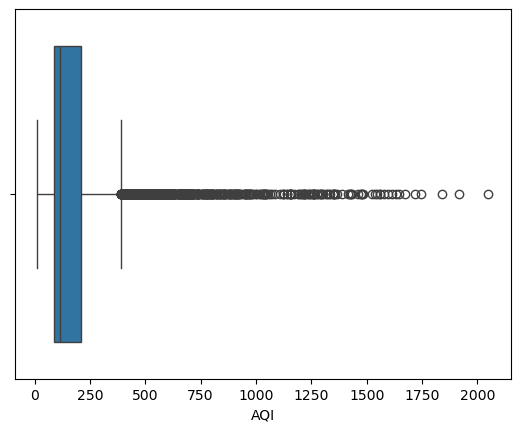

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['AQI'])
plt.show()

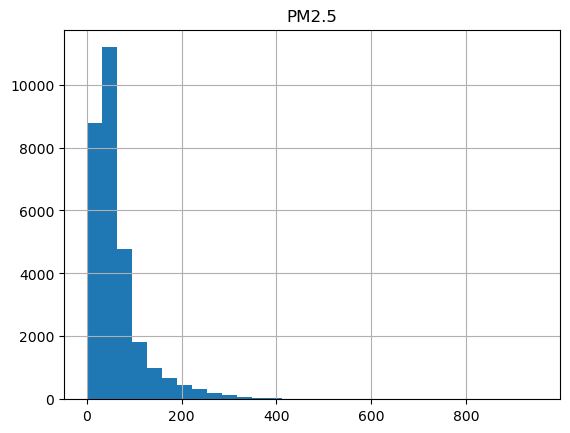

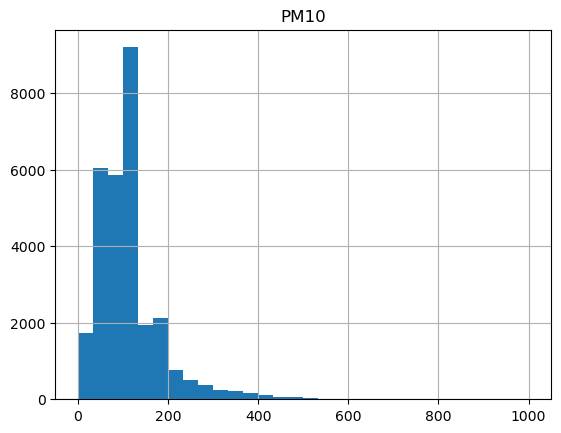

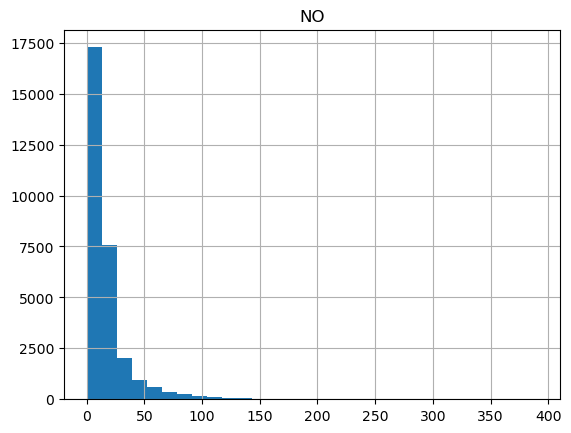

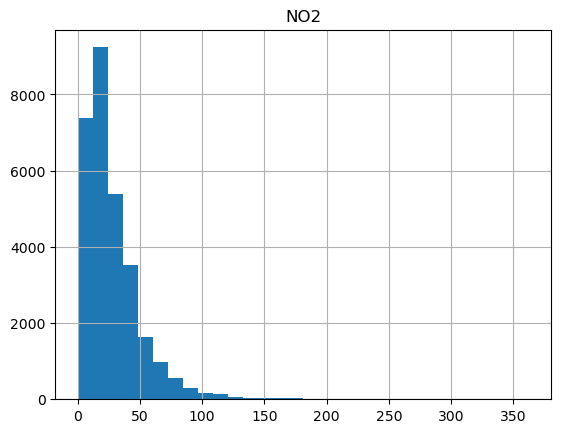

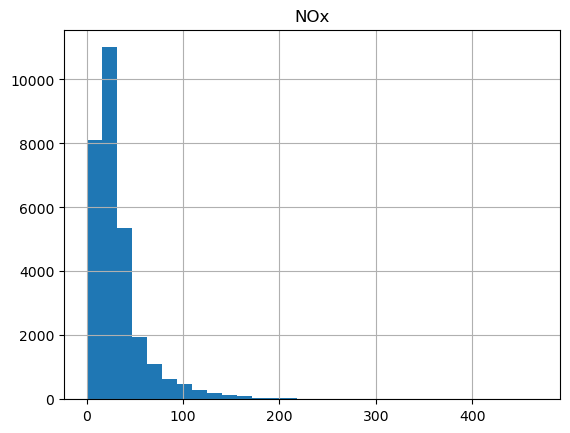

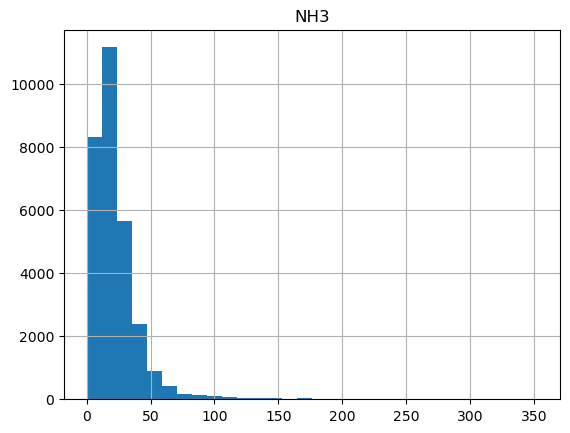

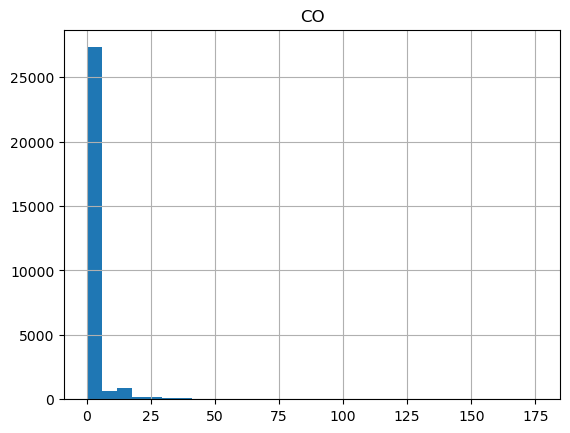

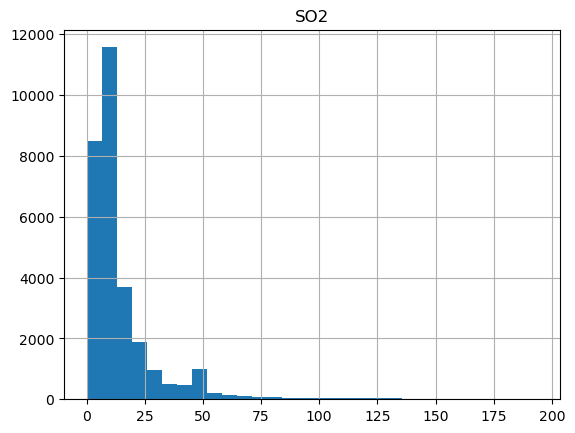

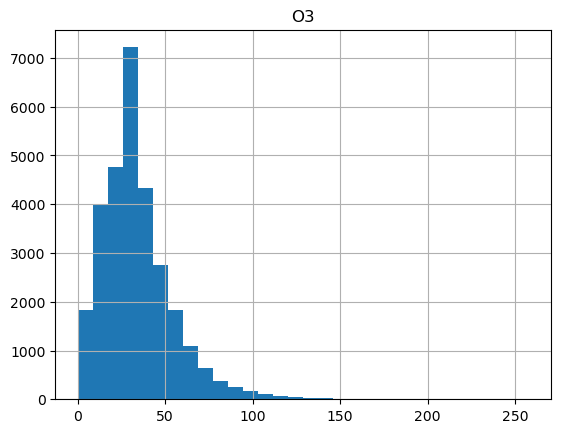

In [36]:
for col in ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [37]:
df[df['AQI'] > 1000][['City','Date','AQI']]

,City,Date,AQI
51,Ahmedabad,2015-02-21,1141.0
53,Ahmedabad,2015-02-23,1247.0
560,Ahmedabad,2016-07-14,1842.0
1029,Ahmedabad,2017-10-26,1426.0
1030,Ahmedabad,2017-10-27,1348.0
...,...,...,...
1749,Ahmedabad,2019-10-16,1190.0
1751,Ahmedabad,2019-10-18,1124.0
1874,Ahmedabad,2020-02-18,1226.0
1875,Ahmedabad,2020-02-19,1291.0


In [38]:
df[df['AQI'] > 1000][['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3']]

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3
51,239.96,107.96,61.95,46.25,106.92,14.5,61.95,84.87,33.55
53,238.41,107.96,77.70,55.07,131.32,14.5,77.70,89.07,37.30
560,38.13,107.96,46.51,48.06,43.98,14.5,46.51,23.13,39.51
1029,112.25,107.96,104.94,36.61,141.28,14.5,104.94,43.78,23.60
1030,133.07,107.96,70.84,51.06,121.90,14.5,70.84,61.91,32.46
...,...,...,...,...,...,...,...,...,...
1749,90.70,188.75,51.18,219.01,162.35,14.5,51.18,135.76,77.07
1751,109.01,174.56,40.53,217.53,148.54,14.5,40.53,46.78,73.44
1874,85.33,163.52,59.34,54.08,67.01,14.5,59.34,64.71,75.45
1875,114.79,217.94,42.62,80.38,70.43,14.5,42.62,118.91,43.63


In [39]:
corr = df.corr(numeric_only=True)
corr['AQI'].sort_values(ascending=False)

AQI        1.000000
CO         0.681945
PM2.5      0.619382
NO2        0.534997
SO2        0.487853
PM10       0.474834
NOx        0.418841
NO         0.407709
Toluene    0.301335
O3         0.202081
NH3        0.088869
Benzene    0.048644
Name: AQI, dtype: float64

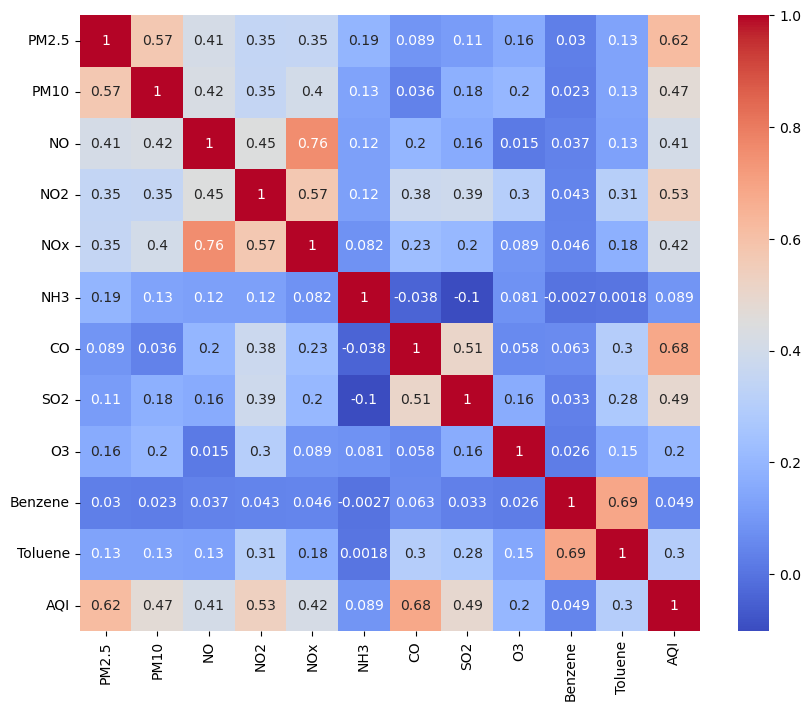

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [41]:
city_aqi = (
    df.groupby('City')['AQI']
      .mean()
      .sort_values(ascending=False)
)

print(city_aqi.head(10))

City
Ahmedabad       429.402439
Delhi           259.475361
Patna           235.245425
Gurugram        222.818940
Lucknow         216.819811
Talcher         161.994054
Jorapokhar      150.313944
Brajrajnagar    143.496802
Guwahati        139.523904
Kolkata         137.133907
Name: AQI, dtype: float64


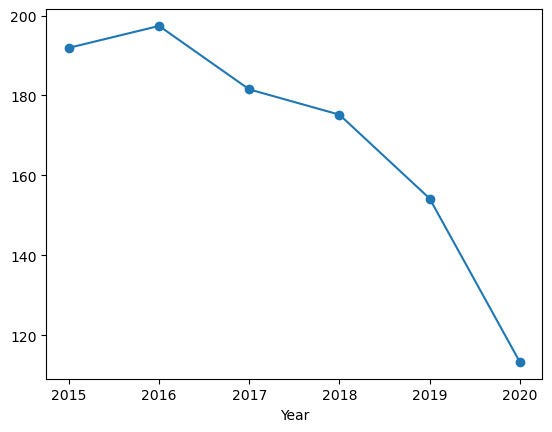

In [42]:
df['Year'] = df['Date'].dt.year

df.groupby('Year')['AQI'].mean().plot(
    kind='line',
    marker='o'
)
plt.show()

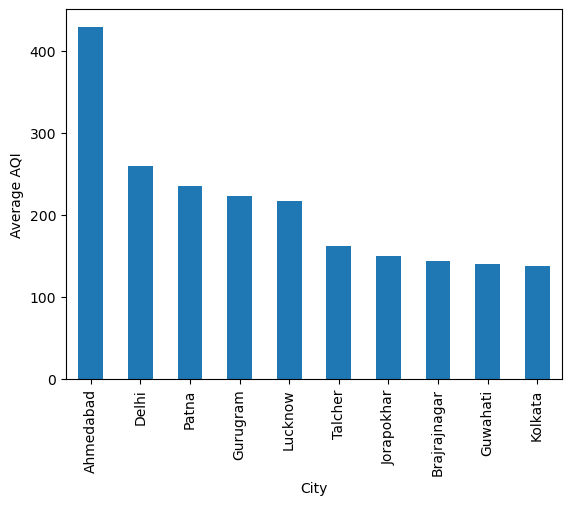

In [43]:
city_aqi.head(10).plot(kind='bar')
plt.ylabel('Average AQI')
plt.show()

In [44]:
df.groupby('Year').size()

Year
2015    2801
2016    3478
2017    4689
2018    6471
2019    7446
2020    4646
dtype: int64

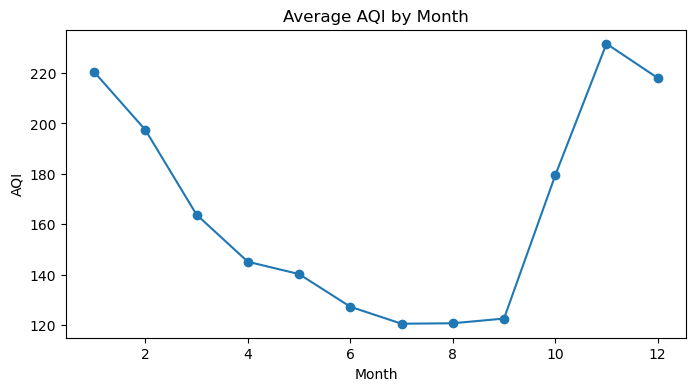

In [45]:
df['Month'] = df['Date'].dt.month

monthly_aqi = df.groupby('Month')['AQI'].mean()

monthly_aqi.plot(
    kind='line',
    marker='o',
    figsize=(8,4)
)

plt.title('Average AQI by Month')
plt.ylabel('AQI')
plt.show()

In [46]:
df.groupby('City').agg({
    'AQI':['mean','median','max','count']
}).sort_values(('AQI','mean'), ascending=False)

AQI                     
                          mean median     max count
City                                               
Ahmedabad           429.402439  384.5  2049.0  2009
Delhi               259.475361  257.0   716.0  2009
Patna               235.245425  215.0   619.0  1858
Gurugram            222.818940  208.0   891.0  1679
Lucknow             216.819811  198.0   707.0  2009
Talcher             161.994054  128.5   570.0   925
Jorapokhar          150.313944  133.0   604.0  1169
Brajrajnagar        143.496802  122.0   355.0   938
Guwahati            139.523904   98.0   956.0   502
Kolkata             137.133907   94.0   475.0   814
Jaipur              133.469479  122.0   457.0  1114
Bhopal              132.339100  120.0   312.0   289
Amritsar            118.448812  101.0   869.0  1221
Visakhapatnam       115.026676  106.0   387.0  1462
Chennai             113.600299  100.0   449.0  2009
Hyderabad           108.880359  104.0   737.0  2006
Kochi               104.154321   99.0   277.0   162
Mumbai               96.536585   91.0   307.0  2009
Chandigarh           96.259868   82.0   335.0   304
Bengaluru            93.908412   86.0   352.0  2009
Amaravati            93.298633   78.0   312.0   951
Ernakulam            92.450617   94.0   180.0   162
Thiruvananthapuram   75.453237   68.0   230.0  1112
Coimbatore           73.238342   75.0   120.0   386
Shillong             51.832258   48.0   182.0   310
Aizawl               34.557522   23.0    92.0   113

In [47]:
df[df['City']=='Ahmedabad'].groupby(
    df['Date'].dt.year
)['AQI'].mean()

Date
2015    331.504110
2016    360.736339
2017    417.443836
2018    617.052055
2019    511.656164
2020    247.516393
Name: AQI, dtype: float64

In [48]:
df[df['City']=='Ahmedabad']['AQI_Bucket'].value_counts()

AQI_Bucket
Very Poor       891
Severe          638
Poor            238
Moderate        198
Satisfactory     43
Good              1
Name: count, dtype: int64

In [49]:
(df['City']=='Ahmedabad') & (df['AQI']>1000)

0        False
1        False
2        False
3        False
4        False
         ...  
29526    False
29527    False
29528    False
29529    False
29530    False
Length: 29531, dtype: bool

In [51]:
# Original mean
df[df['City']=='Ahmedabad']['AQI'].mean()

429.4024390243902

In [52]:
# Mean after removing AQI > 1000
df[(df['City']=='Ahmedabad') & (df['AQI']<=1000)]['AQI'].mean()

386.98982254697285

# Feature Engineering

In [53]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [54]:
def season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(season)

In [55]:
df.to_csv("air_quality_cleaned.csv", index=False)

In [56]:
X = df.drop(['AQI', 'AQI_Bucket', 'Date'], axis=1)
y = df['AQI']

In [57]:
X = pd.get_dummies(
    X,
    columns=['City', 'Season'],
    drop_first=True
)

In [58]:
print(X.shape)

(29531, 41)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(23624, 41)
(5907, 41)


In [60]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(
    y_test,
    y_pred_lr,
    squared=False
)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 28.9834162520239
RMSE: 49.97829595392393
R²  : 0.8497010210991194


C:\Users\mehfo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [62]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [63]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf,
    squared=False
)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

MAE : 19.484915427116142
RMSE: 39.9099154264494
R²  : 0.9041582453452605


C:\Users\mehfo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [64]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
0,PM2.5,0.426750
6,CO,0.407620
2,NO,0.045174
1,PM10,0.037168
7,SO2,0.013419
8,O3,0.013224
4,NOx,0.011909
3,NO2,0.010399
10,Toluene,0.008683
9,Benzene,0.005489


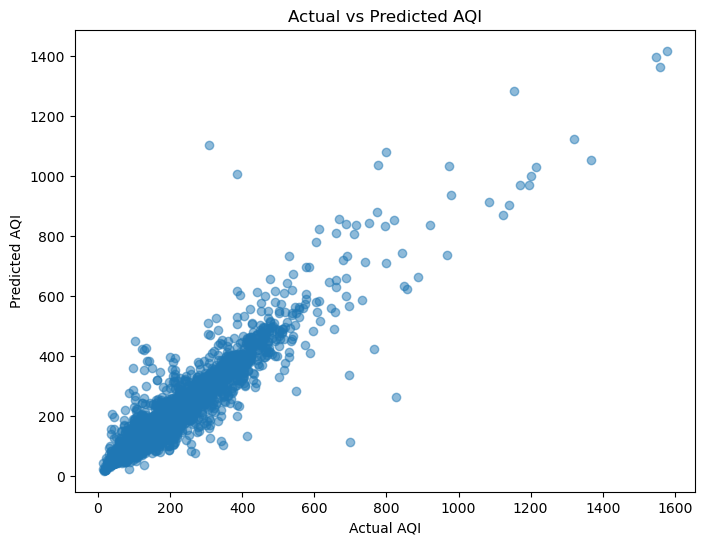

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

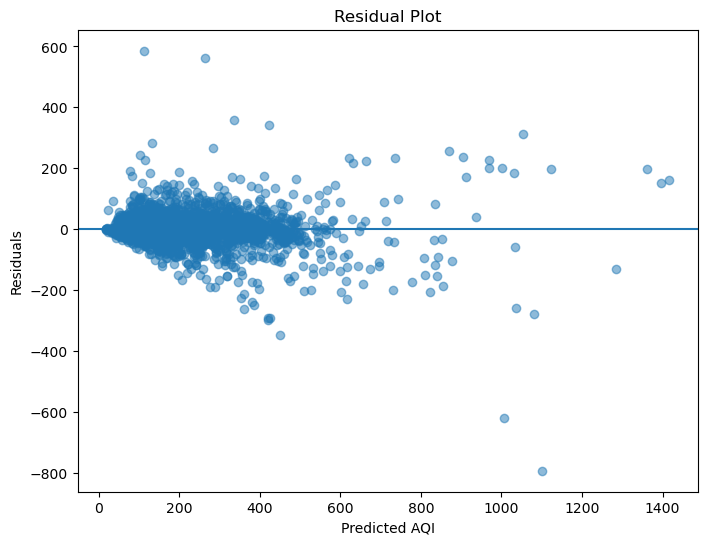

In [66]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

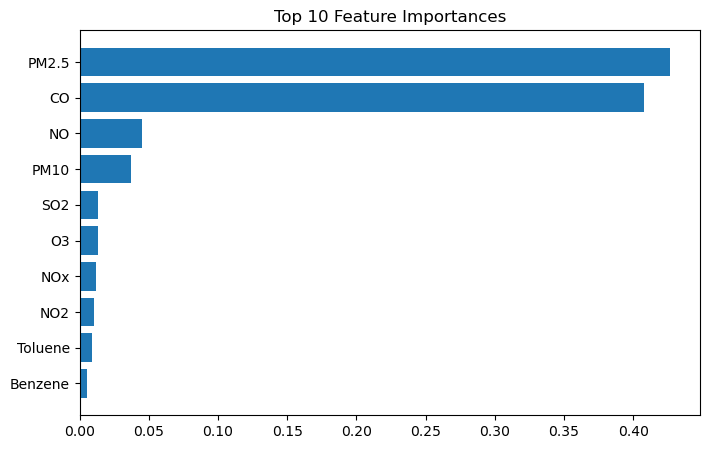

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [69]:
sample = X_test.sample(1, random_state=42)

idx = sample.index[0]

print("Actual AQI:", y.loc[idx])
print("Predicted AQI:", rf.predict(sample)[0])

Actual AQI: 282.0
Predicted AQI: 256.12


In [70]:
for i in range(10):
    sample = X_test.iloc[[i]]

    actual = y_test.iloc[i]
    predicted = rf.predict(sample)[0]

    print(
        f"Actual: {actual:7.2f} | "
        f"Predicted: {predicted:7.2f} | "
        f"Error: {abs(actual-predicted):7.2f}"
    )

Actual:   91.00 | Predicted:   91.00 | Error:    0.00
Actual:   91.00 | Predicted:   91.00 | Error:    0.00
Actual:  137.00 | Predicted:  141.03 | Error:    4.03
Actual:  190.00 | Predicted:  185.54 | Error:    4.46
Actual:  339.00 | Predicted:  357.97 | Error:   18.97
Actual:   82.00 | Predicted:   86.79 | Error:    4.79
Actual:  133.00 | Predicted:  133.00 | Error:    0.00
Actual:  138.00 | Predicted:  135.97 | Error:    2.03
Actual:  111.00 | Predicted:  118.71 | Error:    7.71
Actual:  125.00 | Predicted:   95.45 | Error:   29.55


In [74]:
high_idx = y_test.idxmax()

sample = X.loc[[high_idx]]

actual = y.loc[high_idx]
predicted = rf.predict(sample)[0]

print("Actual AQI:", actual)
print("Predicted AQI:", predicted)
print("Error:", abs(actual - predicted))

Actual AQI: 1577.0
Predicted AQI: 1416.77
Error: 160.23000000000002


In [72]:
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

In [75]:
actual = y.loc[high_idx]
predicted = rf.predict(sample)[0]

category = get_aqi_category(predicted)

print("Actual AQI:", actual)
print("Predicted AQI:", round(predicted, 2))
print("AQI Category:", category)

Actual AQI: 1577.0
Predicted AQI: 1416.77
AQI Category: Severe


In [76]:
sample = X_test.sample(1)

idx = sample.index[0]

actual = y.loc[idx]
predicted = rf.predict(sample)[0]

print(f"Actual AQI: {actual:.2f}")
print(f"Actual Category: {get_aqi_category(actual)}")

print()

print(f"Predicted AQI: {predicted:.2f}")
print(f"Predicted Category: {get_aqi_category(predicted)}")

Actual AQI: 64.00
Actual Category: Satisfactory

Predicted AQI: 56.83
Predicted Category: Satisfactory


In [77]:
import joblib

joblib.dump(rf, "aqi_model.pkl")

['aqi_model.pkl']

## Using most imp features

In [78]:
X = df[['PM2.5', 'CO', 'NO', 'PM10']]
y = df['AQI']

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
from sklearn.ensemble import RandomForestRegressor

rf_4 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_4.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [90]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

pred = rf_4.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R²:", r2_score(y_test, pred))

MAE: 21.575618898033245
RMSE: 42.357941467688086
R²: 0.8920400106721925


In [91]:
import joblib

joblib.dump(rf_4, "aqi_model_4features.pkl")

['aqi_model_4features.pkl']